<a href="https://colab.research.google.com/github/likhith-kumarn/Data_Science/blob/main/naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Naive Bayes Classifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/adult_with_headers (1) (1).csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df.shape

(32561, 15)

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


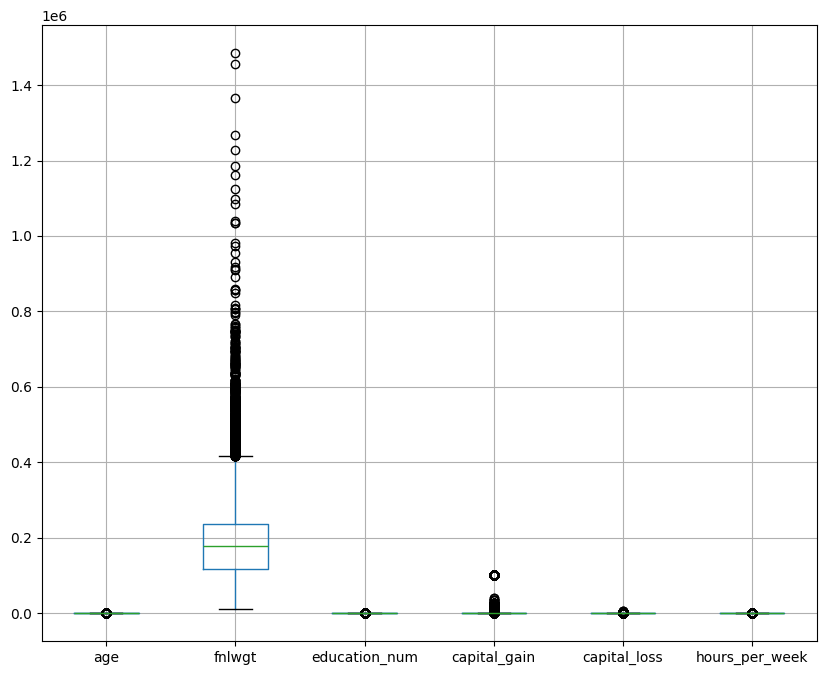

In [13]:
df.boxplot(figsize=(10,8))
plt.show()

In [15]:
Q1 = df['fnlwgt'].quantile(0.25)
Q3 = df['fnlwgt'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['fnlwgt'] >= (Q1 - 1.5 * IQR)) & (df['fnlwgt'] <= (Q3 + 1.5 * IQR))]


In [16]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['age'] >= (Q1 - 1.5 * IQR)) & (df['age'] <= (Q3 + 1.5 * IQR))]


In [17]:
Q1 = df['education_num'].quantile(0.25)
Q3 = df['education_num'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['education_num'] >= (Q1 - 1.5 * IQR)) & (df['education_num'] <= (Q3 + 1.5 * IQR))]

In [18]:
Q1 = df['capital_gain'].quantile(0.25)
Q3 = df['capital_gain'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['capital_gain'] >= (Q1 - 1.5 * IQR)) & (df['capital_gain'] <= (Q3 + 1.5 * IQR))]

In [19]:
Q1 = df['capital_loss'].quantile(0.25)
Q3 = df['capital_loss'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['capital_loss'] >= (Q1 - 1.5 * IQR)) & (df['capital_loss'] <= (Q3 + 1.5 * IQR))]

In [20]:
Q1 = df['hours_per_week'].quantile(0.25)
Q3 = df['hours_per_week'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['hours_per_week'] >= (Q1 - 1.5 * IQR)) & (df['hours_per_week'] <= (Q3 + 1.5 * IQR))]

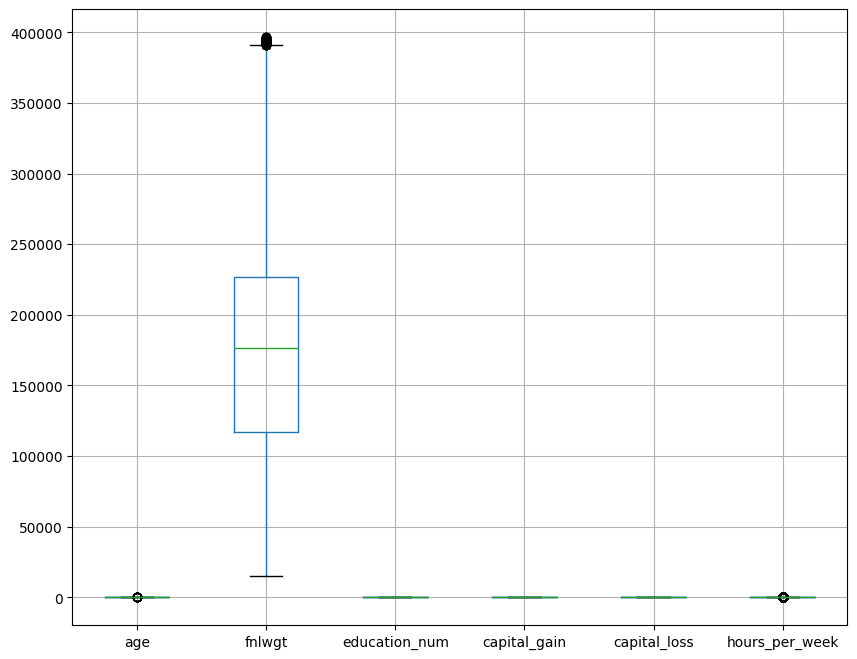

In [21]:
df.boxplot(figsize=(10,8))
plt.show()

In [25]:
categorical = [var for var in df if df[var].dtype=='O']
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [27]:
categorical_col=df[categorical].drop(["income"], axis=1)
categorical_col

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba
5,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,United-States
7,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
...,...,...,...,...,...,...,...,...
32554,Private,Masters,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
32555,Private,Some-college,Never-married,Protective-serv,Not-in-family,White,Male,United-States
32556,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States
32557,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States


In [28]:
df[categorical].isnull().sum()

,0
workclass,0
education,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0
native_country,0
income,0


In [29]:
for var in categorical:
  print(df[var].value_counts())

workclass
Private             13697
Local-gov            1323
Self-emp-not-inc     1091
State-gov             824
?                     739
Federal-gov           653
Self-emp-inc          477
Never-worked            2
Without-pay             2
Name: count, dtype: int64
education
HS-grad         6877
Some-college    4201
Bachelors       3183
Masters          936
Assoc-voc        908
Assoc-acdm       645
11th             575
10th             526
9th              340
12th             238
Prof-school      209
Doctorate        170
Name: count, dtype: int64
marital_status
Married-civ-spouse       8519
Never-married            6008
Divorced                 2941
Separated                 648
Widowed                   445
Married-spouse-absent     235
Married-AF-spouse          12
Name: count, dtype: int64
occupation
Craft-repair         2783
Adm-clerical         2548
Exec-managerial      2359
Prof-specialty       2324
Sales                1880
Other-service        1605
Machine-op-inspct    138

In [30]:
df.workclass.unique()

array([' Private', ' Self-emp-not-inc', ' State-gov', ' Federal-gov',
       ' Local-gov', ' Self-emp-inc', ' ?', ' Never-worked',
       ' Without-pay'], dtype=object)

In [31]:
df.workclass.nunique()

9

In [32]:
df.education.unique()

array([' HS-grad', ' 11th', ' Bachelors', ' Masters', ' Assoc-acdm',
       ' Assoc-voc', ' 9th', ' Some-college', ' Doctorate',
       ' Prof-school', ' 10th', ' 12th'], dtype=object)

In [33]:
df.marital_status.unique()

array([' Divorced', ' Married-civ-spouse', ' Never-married', ' Separated',
       ' Widowed', ' Married-spouse-absent', ' Married-AF-spouse'],
      dtype=object)

In [34]:
df.occupation.unique()

array([' Handlers-cleaners', ' Prof-specialty', ' Exec-managerial',
       ' Sales', ' Craft-repair', ' Farming-fishing',
       ' Machine-op-inspct', ' Tech-support', ' Protective-serv',
       ' Adm-clerical', ' Other-service', ' Transport-moving', ' ?',
       ' Armed-Forces', ' Priv-house-serv'], dtype=object)

In [35]:
df.relationship.unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [36]:
df.race.unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Other',
       ' Amer-Indian-Eskimo'], dtype=object)

In [37]:
df.sex.unique()

array([' Male', ' Female'], dtype=object)

In [38]:
df.native_country.unique()

array([' United-States', ' Cuba', ' India', ' ?', ' Puerto-Rico',
       ' Mexico', ' England', ' Germany', ' Iran', ' Philippines',
       ' Italy', ' Poland', ' Cambodia', ' Laos', ' Portugal', ' France',
       ' El-Salvador', ' Taiwan', ' Dominican-Republic', ' Jamaica',
       ' Honduras', ' Haiti', ' South', ' Japan', ' Yugoslavia',
       ' Canada', ' China', ' Peru', ' Outlying-US(Guam-USVI-etc)',
       ' Scotland', ' Trinadad&Tobago', ' Greece', ' Nicaragua',
       ' Guatemala', ' Vietnam', ' Hong', ' Ireland', ' Columbia',
       ' Ecuador', ' Thailand', ' Hungary'], dtype=object)

In [39]:
df.income.unique()

array([' <=50K', ' >50K'], dtype=object)

In [40]:
df.workclass.value_counts()

,count
workclass,
Private,13697
Local-gov,1323
Self-emp-not-inc,1091
State-gov,824
?,739
Federal-gov,653
Self-emp-inc,477
Never-worked,2
Without-pay,2


In [42]:
df["workclass"].fillna("Unknown", inplace=True)

In [43]:
df.workclass.value_counts()

,count
workclass,
Private,13697
Local-gov,1323
Self-emp-not-inc,1091
State-gov,824
?,739
Federal-gov,653
Self-emp-inc,477
Never-worked,2
Without-pay,2


In [45]:
type('workclass')

str

In [46]:
df[categorical].isnull().sum()

,0
workclass,0
education,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0
native_country,0
income,0


In [47]:
z=df.corr(numeric_only=True)
z

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.064212,0.051231,NaN,NaN,0.049831
fnlwgt,-0.064212,1.000000,-0.023144,NaN,NaN,-0.014394
education_num,0.051231,-0.023144,1.000000,NaN,NaN,0.131226
capital_gain,NaN,NaN,NaN,NaN,NaN,NaN
capital_loss,NaN,NaN,NaN,NaN,NaN,NaN
hours_per_week,0.049831,-0.014394,0.131226,NaN,NaN,1.000000


In [50]:
# Converting categorical data to numerical data
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['workclass']=le.fit_transform(df['workclass'])
df['education']=le.fit_transform(df['education'])
df['marital_status']=le.fit_transform(df['marital_status'])
df['occupation']=le.fit_transform(df['occupation'])
df['relationship']=le.fit_transform(df['relationship'])
df['race']=le.fit_transform(df['race'])
df['sex']=le.fit_transform(df['sex'])
df['native_country']=le.fit_transform(df['native_country'])
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
2,38,4,215646,8,9,0,6,1,4,1,0,0,40,38,<=50K
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,38,<=50K
4,28,4,338409,6,13,2,10,5,2,0,0,0,40,5,<=50K
5,37,4,284582,9,14,2,4,5,4,0,0,0,40,38,<=50K
7,52,6,209642,8,9,2,4,0,4,1,0,0,45,38,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32554,53,4,321865,9,14,2,4,0,4,1,0,0,40,38,>50K
32555,22,4,310152,11,10,4,11,1,4,1,0,0,40,38,<=50K
32556,27,4,257302,4,12,2,13,5,4,0,0,0,38,38,<=50K
32557,40,4,154374,8,9,2,7,0,4,1,0,0,40,38,>50K


In [52]:
#Feature Extraction

x=df.drop(['income'],axis=1)
x.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
2,38,4,215646,8,9,0,6,1,4,1,0,0,40,38
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,38
4,28,4,338409,6,13,2,10,5,2,0,0,0,40,5
5,37,4,284582,9,14,2,4,5,4,0,0,0,40,38
7,52,6,209642,8,9,2,4,0,4,1,0,0,45,38


In [53]:
y=df['income']
y.head()

,income
2,<=50K
3,<=50K
4,<=50K
5,<=50K
7,>50K


In [56]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-0.00792516,  0.09451562,  0.44140959, ...,  0.        ,
        -0.37320015,  0.27592794],
       [ 1.23836661,  0.09451562,  0.66733155, ...,  0.        ,
        -0.37320015,  0.27592794],
       [-0.83878635,  0.09451562,  1.8953995 , ...,  0.        ,
        -0.37320015, -4.1694592 ],
       ...,
       [-0.92187247,  0.09451562,  0.93477814, ...,  0.        ,
        -0.87910295,  0.27592794],
       [ 0.15824707,  0.09451562, -0.28428846, ...,  0.        ,
        -0.37320015,  0.27592794],
       [ 1.6537972 ,  0.09451562, -0.31347177, ...,  0.        ,
        -0.37320015,  0.27592794]])

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [58]:
x_train.shape , x_test.shape , y_train.shape, y_test.shape

((15046, 14), (3762, 14), (15046,), (3762,))

In [59]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_train,y_train)


GaussianNB()

In [60]:
y_pred=model.predict(x_test)
y_pred

array([' <=50K', ' <=50K', ' <=50K', ..., ' >50K', ' <=50K', ' <=50K'],
      dtype='<U6')

In [61]:
pd.DataFrame(y_pred)

,0
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
3757,<=50K
3758,<=50K
3759,>50K
3760,<=50K


In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
accuracy_score(y_test,y_pred)

0.7886762360446571

In [63]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[2460,  532],
       [ 263,  507]])

In [64]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n       <=50K       0.90      0.82      0.86      2992\n        >50K       0.49      0.66      0.56       770\n\n    accuracy                           0.79      3762\n   macro avg       0.70      0.74      0.71      3762\nweighted avg       0.82      0.79      0.80      3762\n'

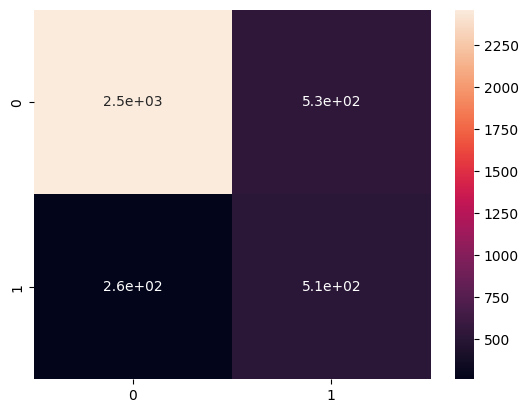

In [65]:
sns.heatmap(cm,annot=True)
plt.show()

In [68]:
y_pred_train=model.predict(x_train)
y_pred_train

array([' <=50K', ' <=50K', ' <=50K', ..., ' >50K', ' <=50K', ' <=50K'],
      dtype='<U6')

In [69]:
pd.DataFrame(y_pred_train)

,0
0,<=50K
1,<=50K
2,<=50K
3,>50K
4,<=50K
...,...
15041,>50K
15042,>50K
15043,>50K
15044,<=50K


In [70]:
print(accuracy_score(y_train, y_pred_train))

0.7895786255483185


In [72]:
#Check Overfitting and underfitting

print("trianing set score:{:.3f}".format(model.score(x_train, y_train)))
print("testing set score:{:.3f}".format(model.score(x_test, y_test)))

trianing set score:0.790
testing set score:0.789


In [73]:
#Calculating the class probability

y_pred_proba = model.predict_proba(x_test)
y_pred_proba

array([[0.99618884, 0.00381116],
       [0.90169635, 0.09830365],
       [0.99263369, 0.00736631],
       ...,
       [0.41564918, 0.58435082],
       [0.9940495 , 0.0059505 ],
       [0.88898027, 0.11101973]])

In [74]:
pd.DataFrame(y_pred_proba)

,0,1
0,0.996189,0.003811
1,0.901696,0.098304
2,0.992634,0.007366
3,0.993734,0.006266
4,0.999919,0.000081
...,...,...
3757,0.960180,0.039820
3758,0.853650,0.146350
3759,0.415649,0.584351
3760,0.994050,0.005950


In [75]:
y_pred_df=pd.DataFrame(data=y_pred_proba, columns=["Prob of >50k","Prob of <=50k"])
y_pred_df

,Prob of >50k,Prob of <=50k
0,0.996189,0.003811
1,0.901696,0.098304
2,0.992634,0.007366
3,0.993734,0.006266
4,0.999919,0.000081
...,...,...
3757,0.960180,0.039820
3758,0.853650,0.146350
3759,0.415649,0.584351
3760,0.994050,0.005950


In [78]:
# store the predicted probabilities for class 1 - Probability of >50K
y_pred1 = model.predict_proba(x_test)[:, 1]
y_pred1

array([0.00381116, 0.09830365, 0.00736631, ..., 0.58435082, 0.0059505 ,
       0.11101973])

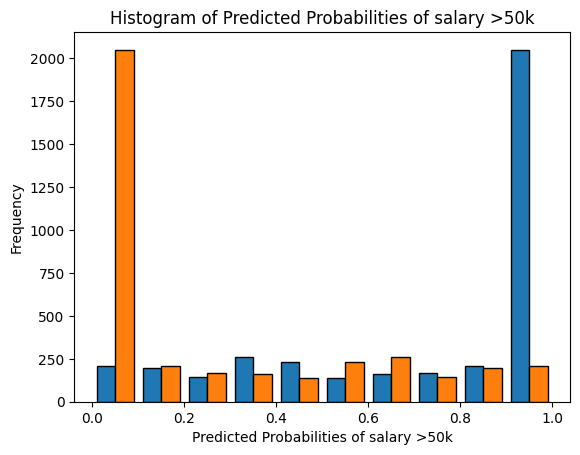

In [79]:
plt.hist(y_pred_proba,bins=10, edgecolor="Black")
plt.title("Histogram of Predicted Probabilities of salary >50k")
plt.xlabel("Predicted Probabilities of salary >50k")
plt.ylabel("Frequency")
plt.show()

In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x_train, y_train, cv = 10, scoring='accuracy')
scores

array([0.76478405, 0.79468439, 0.78870432, 0.78803987, 0.78870432,
       0.80797342, 0.78922872, 0.7918883 , 0.78723404, 0.79388298])

In [81]:
# compute Average cross-validation score

print('Average cross-validation score: {:.4f}'.format(scores.mean()))


Average cross-validation score: 0.7895
